In [75]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
import spharm
import utils 

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

In [ ]:
def compute_hks_simple(V, F, t=1.0, k=100):
    """Simplified version for a single time scale"""
    L = igl.cotmatrix(V, F)
    M = igl.massmatrix(V, F, igl.MASSMATRIX_TYPE_VORONOI)
    
    eigenvalues, eigenvectors = eigsh(L, k=k, M=M, which='LM', sigma=0)
    
    return eigenvalues, eigenvectors

In [ ]:
# Initialize optimizer
m = spharm.SpHarm()

# Load from STL file 
m.load_results('sim/spharm/20')

In [86]:
eigvals, eigvecs = compute_hks_simple(m.v, m.f, t=1.0, k=200)

In [87]:
hks = [] 
for t in [0.1, 1, 10, 100]:
    hks.append(np.einsum('i, ji->j', np.exp(eigvals*t), eigvecs**2))

hks = np.array(hks) 

In [90]:
i = 3
plot(m.v, m.f, c=hks[i], shading={"point_size": 0.1})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001116…

In [74]:
import pyshtools as pysh

coors = m.coors 

theta, phi = m.coors[:, 0], m.coors[:, 1]
        
# Convert to lat/lon
lat, lon = utils.sph2latlon(theta, phi)

spectrums = [] 
for i in range(4):
    x = hks[i]
    
    # Compute SH coefficients
    sh = pysh.SHCoeffs.from_least_squares(x, lat, lon, 15)
    spectrums.append(sh.spectrum()) 

spectrums = np.array(spectrums)

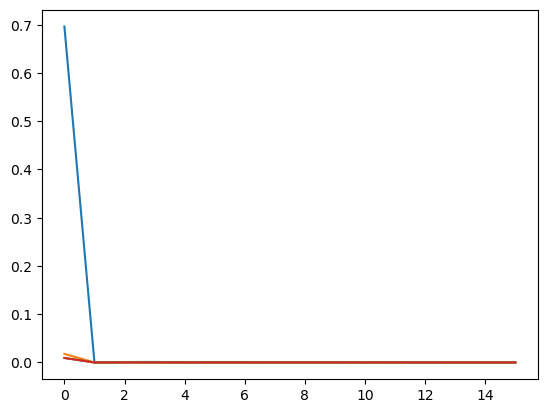

In [76]:
plt.plot(spectrums.T)
plt.show() 